## 7 - Loading Processed Data

In this step, we load processed video dataset from the previously notebook


In [41]:
import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import random
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
import urllib.request

In [42]:
print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_videos/dataframe_videos.csv"
videos = pd.read_csv(load_path)

print(f"{len(videos)} videos loaded!")
pd.set_option('display.max_colwidth', None)
display(videos.sample(15))

--- LOADING PROCESSED DATA ---
7000 videos loaded!


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution
4137,829_808.mp4,1,FaceSwap,classic_829,classic_808,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/829_808.mp4,637,30.0,21.233333,1274x720
4692,043_110.mp4,1,FaceSwap,classic_043,classic_110,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/043_110.mp4,495,30.0,16.500000,1280x720
5510,850_764.mp4,1,NeuralTextures,classic_850,classic_764,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/850_764.mp4,369,30.0,12.300000,800x480
4267,656_666.mp4,1,FaceSwap,classic_656,classic_666,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/656_666.mp4,383,25.0,15.320000,640x480
62,14_09__walking_down_indoor_hall_disgust__6TEK3ZX0.mp4,1,DeepFakeDetection,dfd_14,dfd_09,walking_down_indoor_hall_disgust,6TEK3ZX0,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/14_09__walking_down_indoor_hall_disgust__6TEK3ZX0.mp4,1098,24.0,45.750000,1920x1080
3987,255_214.mp4,1,FaceShifter,classic_255,classic_214,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/255_214.mp4,470,30.0,15.666667,1280x720
3164,368_378.mp4,1,FaceShifter,classic_368,classic_378,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/368_378.mp4,761,30.0,25.366667,640x480
818,28_08__exit_phone_room__5DCAESDA.mp4,1,DeepFakeDetection,dfd_28,dfd_08,exit_phone_room,5DCAESDA,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/28_08__exit_phone_room__5DCAESDA.mp4,466,24.0,19.416667,1920x1080
4018,503_756.mp4,1,FaceSwap,classic_503,classic_756,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/503_756.mp4,570,30.0,19.000000,640x480
1372,367_371.mp4,1,Deepfakes,classic_367,classic_371,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/367_371.mp4,649,25.0,25.960000,640x480


## 8 - Stratified Target-Based and Source-Based Data Split (70/15/15)

In this section, we divide the dataset into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets. To evaluate and **compare** model performance effectively, we implemented two distinct splitting strategies:

1. **Target-Based Split** 
2. **Source-Based Split**

For both approaches, we mathematically guaranteed zero data leakage between the Train and Test sets while maintaining a balanced (stratified) distribution of Real/Fake labels and alteration techniques.

In [43]:
def split(array):
    train_t, temp_t = train_test_split(array, test_size=0.30, random_state=42)
    val_t, test_t = train_test_split(temp_t, test_size=0.50, random_state=42)
    return set(train_t), set(val_t), set(test_t)

def assign_split(series, train_set, val_set, test_set):
    conditions = [
        series.isna(),    
        series.isin(train_set),
        series.isin(val_set),
        series.isin(test_set)
    ]
    
    choices = [
        'unknown',
        'train',
        'val',
        'test'
    ]

    return np.select(conditions, choices, default='unknown')

In [44]:
print("--- TARGET BASED SPLIT ---")

dfd_mask = videos['method'] == "DeepFakeDetection"

dfd_targest = videos[dfd_mask]['target'].dropna().unique()
classic_targets = videos[~dfd_mask]['target'].dropna().unique()

train_trg_dfd, val_trg_dfd, test_trg_dfd = split(dfd_targest)
train_trg_class, val_trg_class, test_trg_class = split(classic_targets)

train_trg_set = train_trg_dfd.union(train_trg_class)
val_trg_set = val_trg_dfd.union(val_trg_class)
test_trg_set = test_trg_dfd.union(test_trg_class)

videos['split_target_based'] = assign_split(videos['target'], train_trg_set, val_trg_set, test_trg_set)

display(videos.sample(10))

--- TARGET BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split_target_based
2474,278.mp4,0,original,classic_278,classic_278,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/278.mp4,449,25.0,17.960000,640x480,test
5011,460_678.mp4,1,NeuralTextures,classic_460,classic_678,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/460_678.mp4,400,30.0,13.333333,1280x720,train
5858,969_897.mp4,1,NeuralTextures,classic_969,classic_897,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/969_897.mp4,333,25.0,13.320000,640x480,train
2154,634.mp4,0,original,classic_634,classic_634,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/634.mp4,338,25.0,13.520000,1280x720,train
625,27_01__hugging_happy__ZYCZ30C0.mp4,1,DeepFakeDetection,dfd_27,dfd_01,hugging_happy,ZYCZ30C0,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/27_01__hugging_happy__ZYCZ30C0.mp4,852,24.0,35.500000,1920x1080,train
4357,192_134.mp4,1,FaceSwap,classic_192,classic_134,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/192_134.mp4,287,30.0,9.566667,1280x720,val
1720,834_852.mp4,1,Deepfakes,classic_834,classic_852,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/834_852.mp4,303,25.0,12.120000,720x480,train
2080,023.mp4,0,original,classic_023,classic_023,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/023.mp4,553,25.0,22.120000,640x480,val
2822,982.mp4,0,original,classic_982,classic_982,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/982.mp4,845,25.0,33.800000,854x480,test
2933,012.mp4,0,original,classic_012,classic_012,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/012.mp4,363,25.0,14.520000,640x480,train


In [45]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split_target_based'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_trg_set.intersection(test_trg_set)
print(f"Targets shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split_target_based'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split_target_based'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split_target_based
train    68.86%
test     15.67%
val      15.47%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Targets shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split_target_based,,
test,13.7%,86.3%
train,14.5%,85.5%
val,13.9%,86.1%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split_target_based,,,,,,,
test,18.0%,13.7%,13.7%,13.7%,13.7%,13.7%,13.7%
train,12.9%,14.5%,14.5%,14.5%,14.5%,14.5%,14.5%
val,16.9%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%


In [46]:
print("--- SOURCE BASED SPLIT ---")

dfd_mask = videos['method'] == "DeepFakeDetection"
dfd_sources = videos[dfd_mask]['source'].dropna().unique()
classic_sources = videos[~dfd_mask]['source'].dropna().unique()

train_src_dfd, val_src_dfd, test_src_dfd = split(dfd_sources)
train_src_class, val_src_class, test_src_class = split(classic_sources)

train_src_set = train_src_dfd.union(train_src_class)
val_src_set = val_src_dfd.union(val_src_class)
test_src_set = test_src_dfd.union(test_src_class)

videos['split_source_based'] = assign_split(videos['source'], train_src_set, val_src_set, test_src_set)

display(videos.sample(10))

--- SOURCE BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split_target_based,split_source_based
6141,131_518.mp4,1,Face2Face,classic_131,classic_518,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/131_518.mp4,295,18.0,16.388889,576x480,test,test
1102,285_136.mp4,1,Deepfakes,classic_285,classic_136,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/285_136.mp4,383,30.0,12.766667,1280x720,train,train
6442,895_915.mp4,1,Face2Face,classic_895,classic_915,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/895_915.mp4,352,25.0,14.080000,832x480,train,train
5145,105_180.mp4,1,NeuralTextures,classic_105,classic_180,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/105_180.mp4,300,30.0,10.000000,640x480,train,train
1148,059_050.mp4,1,Deepfakes,classic_059,classic_050,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/059_050.mp4,721,25.0,28.840000,640x480,train,train
3696,095_053.mp4,1,FaceShifter,classic_095,classic_053,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/095_053.mp4,1006,25.0,40.240000,640x480,train,train
2019,632.mp4,0,original,classic_632,classic_632,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/632.mp4,427,25.0,17.080000,1920x1080,train,train
4396,289_228.mp4,1,FaceSwap,classic_289,classic_228,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/289_228.mp4,556,25.0,22.240000,720x480,train,train
5533,880_135.mp4,1,NeuralTextures,classic_880,classic_135,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/880_135.mp4,327,24.0,13.625000,1920x1080,train,train
70,02_06__talking_angry_couch__GH8TGTBS.mp4,1,DeepFakeDetection,dfd_02,dfd_06,talking_angry_couch,GH8TGTBS,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/02_06__talking_angry_couch__GH8TGTBS.mp4,1278,24.0,53.250000,1920x1080,val,test


In [47]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split_source_based'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_src_set.intersection(test_src_set)
print(f"Sources shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split_source_based'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split_source_based'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split_source_based
train    69.46%
test     15.41%
val      15.13%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Sources shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split_source_based,,
test,13.9%,86.1%
train,14.4%,85.6%
val,14.2%,85.8%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split_source_based,,,,,,,
test,16.6%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%
train,13.6%,14.4%,14.4%,14.4%,14.4%,14.4%,14.4%
val,15.0%,14.2%,14.2%,14.2%,14.2%,14.2%,14.2%


## 9 - Frame Extraction & Preprocessing

To prepare the dataset and maximize temporal variance, we extract **5 equidistant frames** per video and process them through a targeted pipeline:

* **Face Detection & Cropping:** We use OpenCV's DNN (ResNet-10 SSD) to detect faces. Detections are cropped with a 15% margin and padded into a square to prevent aspect-ratio distortion.
* **Fallback Method:** If the model fails to confidently detect a face, we automatically apply a static center crop.
* **Standardization:** All crops are resized to **224x224 pixels** and saved as high-quality JPEGs (`quality=95`) in standardized directory structures (`source_based` and `target_based`). Filenames include specific suffixes (`_ssd` or `_cc`) to track the extraction method used.

In [48]:
# CONFIGURATION
base_root = "F++_Split"
dir_src = "source_based"
dir_trg = "target_based"
fpv = 5
target_size = (224, 224)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

print(f"--- STARTING EXTRACTION: {fpv} FRAMES PER VIDEO ---")
print(f"--- PRIMARY METHOD: OpenCV DNN | FALLBACK: CENTER CROP ---")
print(f"--- TARGET SIZE: {target_size} ---")

# Download models
os.makedirs("models", exist_ok=True)
prototxt_path = "models/deploy.prototxt"
model_path = "models/res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    print("Downloading deploy.prototxt...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        prototxt_path
    )

if not os.path.exists(model_path):
    print("Downloading caffemodel (circa 10 MB)...")
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        model_path
    )

print("Models ready!")

# Load SSD (Face Detector)
net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Center Crop
def apply_static_center_crop(frame, target_size):
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    crop_frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
    return cv2.resize(crop_frame, target_size, interpolation=cv2.INTER_AREA)

# Utility
def is_video_complete(video_name, folder_src, folder_trg, fpv_target):
    src_ok = True
    trg_ok = True
    
    if folder_src:
        if not os.path.exists(folder_src): return False
        frames_src = [f for f in os.listdir(folder_src) if f.startswith(f"{video_name}_f") and f.endswith('.jpg')]
        if len(frames_src) < fpv_target: src_ok = False
            
    if folder_trg:
        if not os.path.exists(folder_trg): return False
        frames_trg = [f for f in os.listdir(folder_trg) if f.startswith(f"{video_name}_f") and f.endswith('.jpg')]
        if len(frames_trg) < fpv_target: trg_ok = False
            
    return src_ok and trg_ok

# MAIN LOOP
for idx, row in tqdm(videos.iterrows(), total=len(videos)):
    video_path = row['path']
    split_src = row.get('split_source_based', 'unknown')
    split_trg = row.get('split_target_based', 'unknown')

    if split_src == 'unknown' and split_trg == 'unknown':
        continue

    label = "original" if row['label'] == 0 else "fake"
    video_name = f"{row['method']}_{os.path.splitext(row['video'])[0]}"

    folder_src = os.path.join(base_root, dir_src, split_src, label) if split_src != 'unknown' else None
    folder_trg = os.path.join(base_root, dir_trg, split_trg, label) if split_trg != 'unknown' else None

    # Checkpoint
    if is_video_complete(video_name, folder_src, folder_trg, fpv):
        continue

    if folder_src: os.makedirs(folder_src, exist_ok=True)
    if folder_trg: os.makedirs(folder_trg, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Errore: Impossibile aprire il video {video_path}")
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < fpv:
        cap.release()
        continue

    target_indices = np.linspace(0, total_frames - 1, fpv, endpoint=False, dtype=int)
    
    for extracted_count, target_idx in enumerate(target_indices):
        # Fast Seeking
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        
        # Save read fallaback
        if not ret:
            cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, target_idx - 5))
            ret, frame = cap.read()
            if not ret:
                continue 

        processed_frame = None
        save_suffix = ""

        # Face Detection via SSD
        (h, w) = frame.shape[:2]
        blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
        net.setInput(blob)
        detections = net.forward()

        if detections.shape[2] > 0:
            confidence = detections[0, 0, 0, 2]
            if confidence > 0.6:
                box = detections[0, 0, 0, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)
                
                w_b, h_b = x2 - x1, y2 - y1
                margin = int(max(w_b, h_b) * 0.15)
                cx1, cy1 = max(0, x1-margin), max(0, y1-margin)
                cx2, cy2 = min(w, x2+margin), min(h, y2+margin)
                
                crop_face = frame[cy1:cy2, cx1:cx2]
                if crop_face.size > 0:
                    fh, fw = crop_face.shape[:2]
                    side = max(fh, fw)
                    square = np.zeros((side, side, 3), np.uint8)
                    square[(side-fh)//2 : (side-fh)//2+fh, (side-fw)//2 : (side-fw)//2+fw] = crop_face
                    processed_frame = cv2.resize(square, target_size, interpolation=cv2.INTER_AREA)
                    save_suffix = "ssd"

        # Fallback if SSD fails
        if processed_frame is None:
            processed_frame = apply_static_center_crop(frame, target_size)
            save_suffix = "cc"

        # Saving process
        frame_filename = f"{video_name}_f{extracted_count}_{save_suffix}.jpg"
        
        for folder in [folder_src, folder_trg]:
            if folder:
                save_path = os.path.join(folder, frame_filename)
                cv2.imwrite(save_path, processed_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

    cap.release()

print("\n--- EXTRACTION COMPLETE ---")
print(f"Data saved successfully under the '{base_root}/' directory.")

Running on device: cpu
--- STARTING EXTRACTION: 5 FRAMES PER VIDEO ---
--- PRIMARY METHOD: OpenCV DNN | FALLBACK: CENTER CROP ---
--- TARGET SIZE: (224, 224) ---
Models ready!


  0%|          | 0/7000 [00:00<?, ?it/s]

100%|██████████| 7000/7000 [01:38<00:00, 71.32it/s] 


--- EXTRACTION COMPLETE ---
Data saved successfully under the 'F++_Split/' directory.


## 10 - Visual Sanity Check 

This serves as a critical "sanity check" to verify that the frame extraction process completed successfully without generating corrupted or blank images

In [49]:
fpv = 5
base_root = "F++_Split"

print("--- SANITY CHECK ---")

# Calculate Expected Frames from DataFrame
if 'split_source_based' in videos.columns:
    src_valid = videos[videos['split_source_based'] != 'unknown']
else:
    src_valid = []

if 'split_target_based' in videos.columns:
    trg_valid = videos[videos['split_target_based'] != 'unknown']
else:
    trg_valid = []

expected_src = len(src_valid) * fpv
expected_trg = len(trg_valid) * fpv

# Count Actual Frames on Disk
def count_frames_and_methods(base_dir):
    if not os.path.exists(base_dir):
        return 0, 0, 0
    total, ssd, cc = 0, 0, 0
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.jpg'):
                total += 1
                if '_ssd' in file:
                    ssd += 1
                elif '_cc' in file:
                    cc += 1
    return total, ssd, cc

dir_src_path = os.path.join(base_root, "source_based")
dir_trg_path = os.path.join(base_root, "target_based")

actual_src, src_ssd, src_cc = count_frames_and_methods(dir_src_path)
actual_trg, trg_ssd, trg_cc = count_frames_and_methods(dir_trg_path)

def print_stats(name, expected, actual, ssd, cc):
    print(f"\n--- {name.upper()} STATISTICS ---")
    print(f"Valid videos in DataFrame: {expected // fpv if expected > 0 else 0}")
    print(f"EXPECTED frames:           {expected}")
    print(f"FOUND frames:              {actual}")
    
    if expected == actual and expected > 0:
        print("STATUS: PERFECT! The numbers match.")
    elif actual == 0:
        print("STATUS: WARNING/INFO! No frames found in this directory.")
    else:
        print(f"STATUS: MISMATCH! Missing {expected - actual} frames.")
        
    if actual > 0:
        print(f"  -> SSD Faces:   {ssd} ({(ssd/actual)*100:.1f}%)")
        print(f"  -> Center Crop:   {cc} ({(cc/actual)*100:.1f}%)")

print_stats("SOURCE_BASED", expected_src, actual_src, src_ssd, src_cc)
print_stats("TARGET_BASED", expected_trg, actual_trg, trg_ssd, trg_cc)

print(f"\nTotal frames expected across both splits: {expected_src + expected_trg}")
print(f"Total frames found across both splits:    {actual_src + actual_trg}")

--- SANITY CHECK ---

--- SOURCE_BASED STATISTICS ---
Valid videos in DataFrame: 7000
EXPECTED frames:           35000
FOUND frames:              35000
STATUS: PERFECT! The numbers match.
  -> SSD Faces:   34147 (97.6%)
  -> Center Crop:   853 (2.4%)

--- TARGET_BASED STATISTICS ---
Valid videos in DataFrame: 7000
EXPECTED frames:           35000
FOUND frames:              35000
STATUS: PERFECT! The numbers match.
  -> SSD Faces:   34147 (97.6%)
  -> Center Crop:   853 (2.4%)

Total frames expected across both splits: 70000
Total frames found across both splits:    70000



--- VISUALIZING RANDOM FRAMES ---


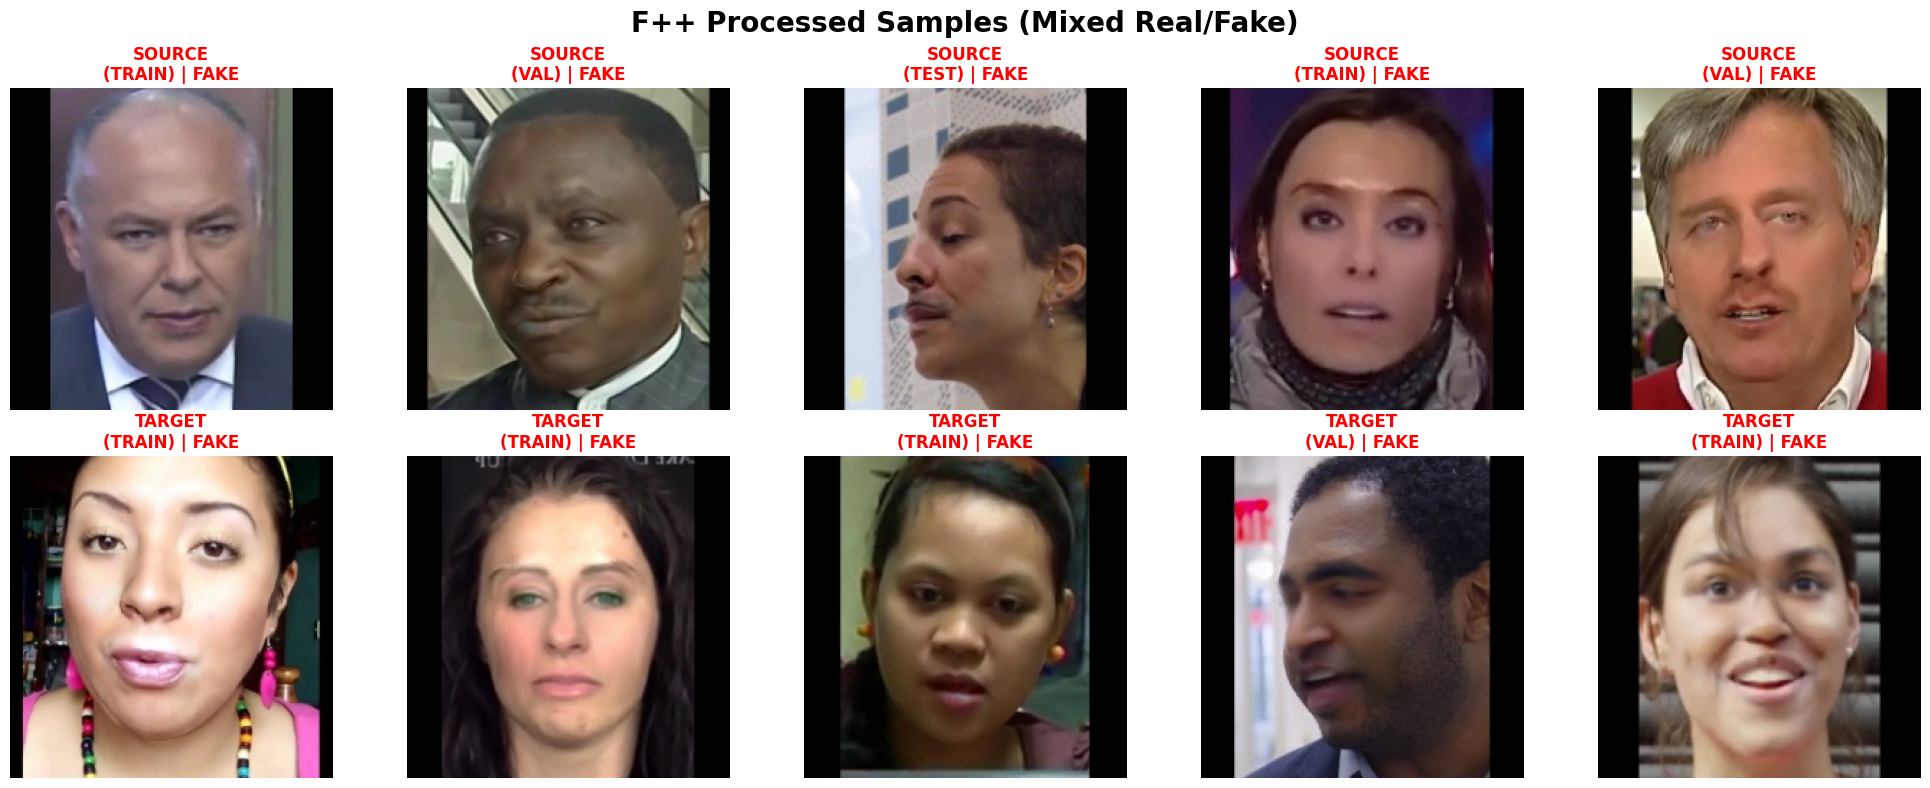

In [50]:
def get_random_frames(base_root, num_images, split_type):
    """Helper function to extract N random frames from a specific folder."""
    all_frames = []
    
    if not os.path.exists(base_root):
        return []

    for root, dirs, files in os.walk(base_root):
        for file in files:
            if file.endswith(".jpg"):
                full_path = os.path.join(root, file)
                parts = root.split(os.sep)
                
                subset = parts[-2] 
                folder_label = parts[-1] 
                
                label = "REAL" if folder_label == "original" else "FAKE"
                all_frames.append((full_path, subset, label, split_type))
    
    if not all_frames:
        return []
        
    return random.sample(all_frames, min(num_images, len(all_frames)))

def show_both_splits_frames():
    print("\n--- VISUALIZING RANDOM FRAMES ---")

    sample_src = get_random_frames("F++_Split/source_based", fpv, "SOURCE")
    sample_trg = get_random_frames("F++_Split/target_based", fpv, "TARGET")
    
    sample = sample_src + sample_trg
    
    if not sample:
        print("No images found...")
        return 

    cols = 5
    rows = math.ceil(len(sample) / cols)
    
    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle("F++ Processed Samples (Mixed Real/Fake)", fontsize=20, fontweight='bold')

    for i, (img_path, subset, label, split_type) in enumerate(sample):
        plt.subplot(rows, cols, i+1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.axis('off')

        title_color = 'green' if label == "REAL" else 'red'
        plt.title(f"{split_type}\n({subset.upper()}) | {label}", color=title_color, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_both_splits_frames()

In [51]:
print("--- SAVING DATAFRAME ---")

output_dir = "./processed_videos"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "dataframe_videos_final.csv")
videos.to_csv(save_path, index=False)

print(f"Data succesfully saved to: {save_path}")

--- SAVING DATAFRAME ---
Data succesfully saved to: ./processed_videos/dataframe_videos_final.csv
